# Dynamics of the Hair Follicle: An SIR-Based Analysis of Biochemical Activation and Hormonal Inhibition.

In [1]:
import base64
from IPython.display import HTML, display
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
from tabulate import tabulate
from statsmodels.stats.diagnostic import het_arch
from statsmodels.graphics.tsaplots import plot_acf

def draw_mermaid_centered(graph_code):
    graphbytes = graph_code.encode("ascii")
    base64_string = base64.b64encode(graphbytes).decode("ascii")
    url = "https://mermaid.ink/img/" + base64_string
    
    # Use the legacy <center> tag which Jupyter usually respects
    display(HTML(f'<center><img src="{url}"></center>'))

    
def print_styled(text, color="black"):
    # Centers, bolds, and colors the text in one line
    display(HTML(f'<div style="text-align:center; color:{color}; font-weight:bold; font-size:14px;">{text}</div>'))



my_graph = """
graph TD
A((A)) --> C((C))
C --> T((T))
T --> A
"""

draw_mermaid_centered(my_graph)
print_styled("A State Machine Representation of the Human Hair Follicular Transition")


## Extended SIR model for the follicle life cycle

The graph above is a state machine representation of the life cycle of a follicle where:

- A &nbsp; Anagen is a growing state
- C &nbsp; Catagen is a transition stage
- T &nbsp; Talogen is a resting state

We propose SIR-like modeling:

$$
\frac{dA}{dt} = k_{wake}(\frac{w_{nt}^n}{w_{nt}^n + k_{wnt}^n})T - A(\beta_{base} + \beta_{max}(\frac{FGF5^n}{FGF5^n + K_{FGF5}^n} .\frac{DHT^m}{DHT^m + K_{DHT}^m} ))
$$
$$
\frac{dC}{dt} = A(\beta_{base} + \beta_{max}(\frac{FGF5^n}{FGF5^n + K_{FGF5}^n} .\frac{DHT^m}{DHT^m + K_{DHT}^m} )) - \gamma C
$$
$$
\frac{dT}{dt} =  \gamma C - k_{wake}(\frac{w_{nt}^n}{w_{nt}^n + k_{wnt}^n})T
$$
where:
- $k_{wake}$ is the maximum fraction of T that converts to A at a time
- $w_{nt}$ is a protein signaling awakening of follicles (converting from Talogen to Anagen)
- FGF5 is a protein that signals the transition from Anagen to Catagen. It is a growth inhibitor.
- DHT is a hormone that accelerates the FGF5 effect.
- $\gamma$ is the C to T conversion rate. It solely depends on the biological clock, not on hormones or proteins.

Treatments like minoxidal lowers the $k_{wnt}$ and Finosteride reduces DHT

Parameter variations:

- $K_{FGF5}$ and $K_{DHT}$ vary from person to person as they have strong genetic dependency
- DHT varies depending on age and health condition. More DHT at older ages.
- FGF5 and $W_{nt}$ can be assumed among people as they are produced at the same rate and quantity.
- $K_{wnt}$ also depends on genetics but can be assumed constant for people of similar age and health condition.


## Nonlinear regression to determine the parameters in the extended-SIR model.

There are no publicly available clinical datasets on hair loss or hair treatment that are directly relevant to this project. In particular, longitudinal measurements—such as follicle counts in the anagen (A) and telogen (T) phases, average follicle diameter, and related metrics—would be highly valuable. Such data could be used in a regression framework to estimate the parameters of an SIR-type model describing follicle state dynamics.

In the absence of suitable public datasets, we relied on Halloy et al. to generate synthetic data. Their work models the transition times between follicle states using log-normal distributions parameterized by experimentally derived values. Building on this framework, we conducted an agent-based simulation to produce longitudinal data, specifically tracking the number of follicles in the anagen (A), catagen (C), and telogen (T) states over time. We then fit the extended SIR model to the mean trajectories obtained by averaging across multiple simulation runs. 

The duration of each follicular phase is modeled using a log-normal distribution:

$$
f(x;\,\mu,\sigma)
= \frac{1}{x\,\sigma\sqrt{2\pi}}
\exp\!\left(
-\frac{(\log x - \mu)^2}{2\sigma^2}
\right),
\qquad x>0 \tag{1}
$$

The mean ($m$) and variance ($v$) of these durations are derived from experimental data. Using the moment-generating function, the parameters for the log-normal distribution are calculated as:

$$
\sigma _{\log }^2=\ln \! \left( 1+\frac{v}{m^2}\right) \tag{2a}
$$

$$
\mu _{\log }=\ln (m)-\frac{1}{2}\sigma _{\log }^2 \tag{2b}
$$



## I. Generate Synthetic Data

In [2]:
#---------------------------------------------------------
# 1. Log-normal duration sampler
#    (Phase durations drawn from empirical distributions)
#---------------------------------------------------------
def sample_duration(mu, sigma):
    """Sample a phase duration from the log-normal distribution in Eq. (1)."""
    return np.random.lognormal(mean=mu, sigma=sigma)


#---------------------------------------------------------
# 2. Probability of transition into pathological state M
#    (Slowly increasing probability as cycles accumulate)
#---------------------------------------------------------
def p_to_M(cycles):
    """Slowly increasing probability of transitioning to M."""
    return min(0.01 * (1 + 0.1 * cycles), 0.2)


#---------------------------------------------------------
# 3. Baseline follicle-cycle structure (A → C → T → A)
#---------------------------------------------------------
next_phase = {
    "A": "C",
    "C": "T",
    "T": "A"
}


#-----------------------------------------------------------
# 4. Phase-duration parameters for A, T, L, and optional M
#-----------------------------------------------------------
def convert_to_lognormal_params(mean, variance):
    sigma2_log = np.log(1 + variance / (mean**2))
    sigma_log = np.sqrt(sigma2_log)
    mu_log = np.log(mean) - 0.5 * sigma2_log
    return mu_log, sigma_log



#---------------------------------------------------------
# 5. Phase-transition rule
#    (Normal cycling or optional transition into M)
#---------------------------------------------------------
def choose_next_phase(phase, cycles, include_M=False):
    """
    Determine the next phase in the follicle cycle.
    If include_M=True, allow a slow-probability transition to M.
    """
    # If follicle is already in M, it stays there
    if phase == "M":
        return "M"

    # Normal cycle transitions
    next_phase_map = {"A": "C", "C": "T", "T": "A"}

    # If M transitions are disabled
    if not include_M:
        return next_phase_map[phase]

    # Otherwise include slow probability to M
    pM = p_to_M(cycles)

    if np.random.rand() < pM:
        return "M"
    else:
        return next_phase_map[phase]


#---------------------------------------------------------
# 6. Simulate a single follicle over T_end months
#---------------------------------------------------------
def simulate_follicle(T_end, initial_phase, include_M=False):
    phase = initial_phase
    cycles = 0
    time_to_transition = sample_duration(*phase_params[phase])

    phases = []
    cycle_counts = []

    for t in range(T_end):

        # If already in M, stay in M
        if phase == "M":
            phases.append("M")
            cycle_counts.append(cycles)
            continue

        phases.append(phase)
        cycle_counts.append(cycles)

        time_to_transition -= 1

        if time_to_transition <= 0:

            # Use the new choice function
            phase = choose_next_phase(phase, cycles, include_M=include_M)

            # If moved to M, no new duration needed
            if phase == "M":
                continue

            # Otherwise sample new duration
            time_to_transition = sample_duration(*phase_params[phase])

            # Count cycles when entering A
            if phase == "A":
                cycles += 1

    return phases, cycle_counts



#---------------------------------------------------------
# 7. Simulate a population of independent follicles
#---------------------------------------------------------
def simulate_population(N_follicles, T_end, initial_phase, include_M=False, cooling=3):
    all_phases = []
    all_cycles = []
    for i in range(N_follicles):
        phases, cycles = simulate_follicle(T_end, initial_phase, include_M=include_M)
        all_phases.append(phases)
        all_cycles.append(cycles)
      
    # Convert both to numpy arrays for easier slicing/math
    return np.array(all_phases), np.array(all_cycles)


#---------------------------------------------------------
# 8. Population-level statistics at a given time t
#---------------------------------------------------------
def population_statistics(all_phases, all_cycles, t=None):
    """
    Compute counts for A, C, and T. 
    Include M only if it exists in the data.
    """
    # Slice the data based on whether a specific time t is provided
    if t is not None:
        target_data = all_phases[:, t]
        axis = None # Summing a 1D slice
    else:
        target_data = all_phases
        axis = 0    # Summing across follicles for each time step

    # Standard phases
    stats = {
        "A": np.sum(target_data == "A", axis=axis),
        "C": np.sum(target_data == "C", axis=axis),
        "T": np.sum(target_data == "T", axis=axis),
    }

    # Add M only if it is present in the data
    if np.any(target_data == "M"):
        stats["M"] = np.sum(target_data == "M", axis=axis)

    return stats



#---------------------------------------------------------
# 9. Paired simulations: with-M vs without-M transitions
#---------------------------------------------------------
def run_two_simulations(N, T_end):
    # With M transitions
    phases_M, cycles_M = simulate_population(N, T_end, include_M=True, cooling =3)

    # Without M transitions
    phases_noM, cycles_noM = simulate_population(N, T_end, include_M=False, cooling =3)

    return (phases_M, cycles_M), (phases_noM, cycles_noM)



#---------------------------------------------------------
# 10. Multi-Subject Population Simulation
#---------------------------------------------------------
def run_subject_populations(params, N=1000, T_end=200, n_simulation=25, include_M=False):
    global phase_params
    phase_params = params
    
    A, C, T, M = [], [], [], []
    
    for i in range(n_simulation):
        rnd = np.random.rand()
        
        if rnd < 0.50:
            initial_phase = 'A'

        elif rnd < 0.80:
            initial_phase = 'T'

        else:
            initial_phase = 'C'
        
        # Pass include_M into the simulation
        all_phases, all_cycles = simulate_population(N, T_end, initial_phase=initial_phase, include_M=include_M)
        data = population_statistics(all_phases, all_cycles)
        
        A.append(data['A'])
        C.append(data['C'])
        T.append(data['T'])
        if 'M' in data:
            M.append(data['M'])
            
    # Conditional return
    if include_M and len(M) > 0:
        return np.array(A), np.array(C), np.array(T), np.array(M)
    else:
        return np.array(A), np.array(C), np.array(T)



In [3]:
#----------------------------------------------------------
# 11. Generate follicle-cycle Data for baseline structure 
#  (A → C → T → A)
#----------------------------------------------------------   


mu_M = 3.0      # example mean duration of M
var_M = 2.0     # example variance of M


# Subject 1:
phase_params1 = {
    "A": convert_to_lognormal_params(16.91, 19.49**2),
    "C": convert_to_lognormal_params(1.79, 0.82**2),
    "T": convert_to_lognormal_params(5.23, 5.18**2),
}


# Subject 2:
phase_params2 = {
    "A": convert_to_lognormal_params(5.16, 4.50**2),
    "C": convert_to_lognormal_params(2.09, 1.06**2),
    "T": convert_to_lognormal_params(3.53, 5.43**2),
}


# Subject 3
phase_params3 = {
    "A": convert_to_lognormal_params(6.49, 10.16**2),
    "C": convert_to_lognormal_params(2.17, 1.11**2),
    "T": convert_to_lognormal_params(4.56, 9.57**2),
}



N_value = 1000
T_end_value=200
n_sim_value=25

# Running simulation for subjects 1 & 2 only:
A1, C1, T1 = run_subject_populations(phase_params1, N=N_value, T_end=T_end_value, n_simulation=n_sim_value)
A2, C2, T2 = run_subject_populations(phase_params2, N=N_value, T_end=T_end_value, n_simulation=n_sim_value)


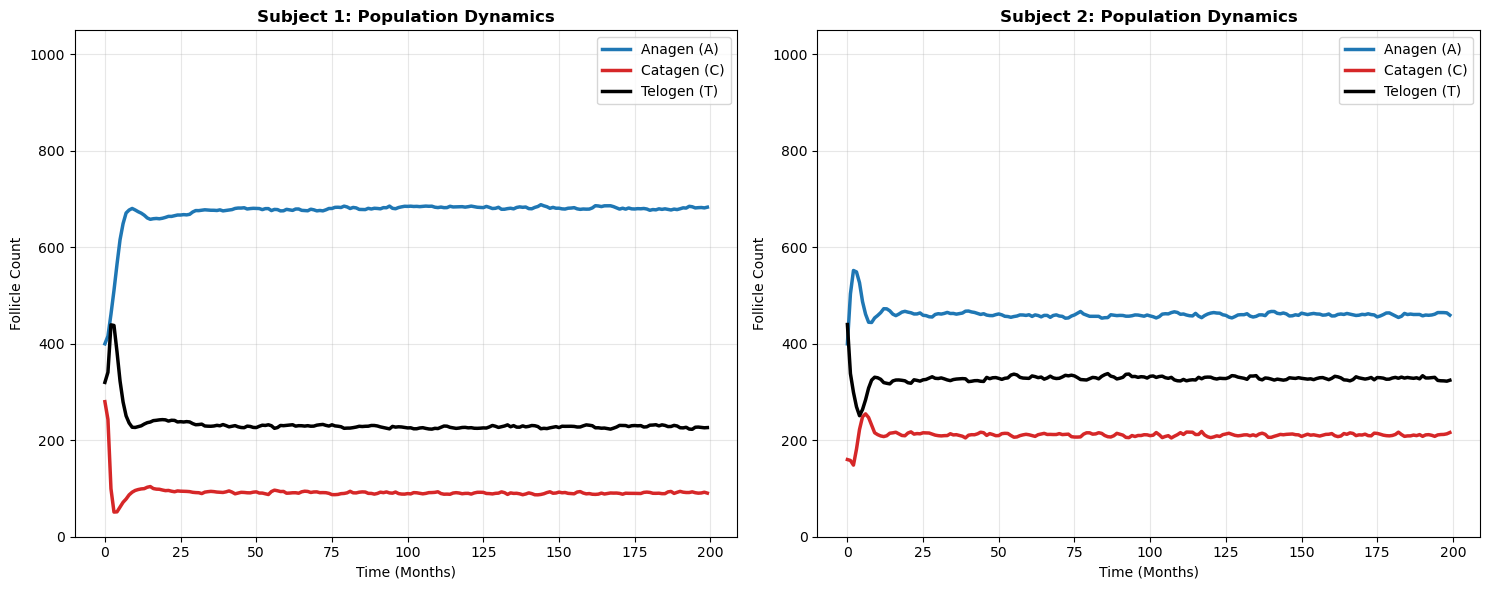

In [4]:
#-------------------------------------------------------
# Plotting follicle-cycle Data for baseline structure
#-------------------------------------------------------

colors = ['#1f77b4', '#d62728', '#000000'] # Blue (A), Red (C), Black (T)
labels = ['Anagen (A)', 'Catagen (C)', 'Telogen (T)']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

plot_setup = [
    {"name": "Subject 1", "data": [A1, C1, T1], "ax": axes[0]},
    {"name": "Subject 2", "data": [A2, C2, T2], "ax": axes[1]}
]

for setup in plot_setup:
    ax = setup["ax"]
    # A, C, T are shape (25, 200)
    A_mean = np.mean(setup["data"][0], axis=0)
    C_mean = np.mean(setup["data"][1], axis=0)
    T_mean = np.mean(setup["data"][2], axis=0)
    
    means = [A_mean, C_mean, T_mean]
    
    for i in range(3):
        ax.plot(range(T_end_value), means[i], color=colors[i], label=labels[i], linewidth=2.5)

    # Formatting
    ax.set_title(f"{setup['name']}: Population Dynamics", fontweight='bold')
    ax.set_xlabel('Time (Months)')
    ax.set_ylabel('Follicle Count')
    ax.set_ylim(0, N_value + 50) # Set limit based on N
    ax.legend(loc='upper right')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [5]:
#--------------------------------------------------------------------
# Generate follicle-cycle Data with Pathological state (M) included
#--------------------------------------------------------------------

# This code never runs
if False:
    # Define New Dictionaries for M-simulations
    phase_params1_M = phase_params1.copy()
    phase_params1_M["M"] = convert_to_lognormal_params(mu_M, var_M**2)
    
    phase_params2_M = phase_params2.copy()
    phase_params2_M["M"] = convert_to_lognormal_params(mu_M, var_M**2)
    
    phase_params3_M = phase_params3.copy()
    phase_params3_M["M"] = convert_to_lognormal_params(mu_M, var_M**2)
    
    # Run with 4 return variables
    A1_M, C1_M, T1_M, M1 = run_subject_populations(phase_params1_M, N=1000, include_M=True)
    A2_M, C2_M, T2_M, M2 = run_subject_populations(phase_params2_M, N=1000, include_M=True)
    A3_M, C3_M, T3_M, M3 = run_subject_populations(phase_params3_M, N=1000, include_M=True)


# II. Normalize and Apply Nonlinear Regression

Normalized ODEs:


$$
\frac{dA}{dt} = k_{wake}(\frac{w_{nt}^n}{w_{nt}^n + k_{wnt}^n})T - A(\beta_{base} + \beta_{max}(\frac{FGF5^n}{FGF5^n + K_{FGF5}^n} .\frac{DHT^m}{DHT^m + K_{DHT}^m} ))
$$
$$
\frac{dC}{dt} = A(\beta_{base} + \beta_{max}(\frac{FGF5^n}{FGF5^n + K_{FGF5}^n} .\frac{DHT^m}{DHT^m + K_{DHT}^m} )) - \gamma C
$$
$$
\frac{dT}{dt} =  \gamma C - k_{wake}(\frac{w_{nt}^n}{w_{nt}^n + k_{wnt}^n})T
$$

Define:

- N = A + T + C
- a  = $\frac{A}{N}$
- c  = $\frac{C}{N}$
- r  = $\frac{T}{N}$

- $\alpha$ =  $k_{wake}(\frac{w_{nt}^n}{w_{nt}^n + k_{wnt}^n})$
- $\beta$ = $(\beta_{base} + \beta_{max}(\frac{FGF5^n}{FGF5^n + K_{FGF5}^n}.\frac{DHT^m}{DHT^m + K_{DHT}^m} )) $

The equation simplifies to:
$$
\frac{da}{dt} = \alpha r - \beta a
$$
$$
\frac{dc}{dt} = \beta a - \gamma c
$$
$$
\frac{dr}{dt} =  \gamma c - \alpha r
$$


In [6]:
# ---------------------------------------------------
# Normalizing Subject Follicle Data (baseline cycle)
# ---------------------------------------------------

# Assemble subject data together
subjects_data = [
    {"name": "Subject 1", "data": [A1, C1, T1]},
    {"name": "Subject 2", "data": [A2, C2, T2]},
    # Add Subject 3 here if you ran it: {"name": "Subject 3", "data": [A3, C3, T3]}
]


# Process and Normalize data for each subject
t_data = np.arange(T_end_value)
results = {}

for sub in subjects_data:
    # sub["data"] => [A, C, T] => along (axis=1) 
    # then transpose and divide by N to get proportions (0 to 1)
    avg_counts = np.mean(sub["data"], axis=1).T 
    norm_data = avg_counts / N_value  # N = N_value
    
    results[sub["name"]] = {
        "norm_data": norm_data,
        "x0": norm_data[0] # Initial proportions for solve_ivp
    }

# Check shape of normalized data
print(f"Shape for Subject 1: {results['Subject 1']['norm_data'].shape}")
print(f"Shape for Subject 2: {results['Subject 2']['norm_data'].shape}")

Shape for Subject 1: (200, 3)
Shape for Subject 2: (200, 3)


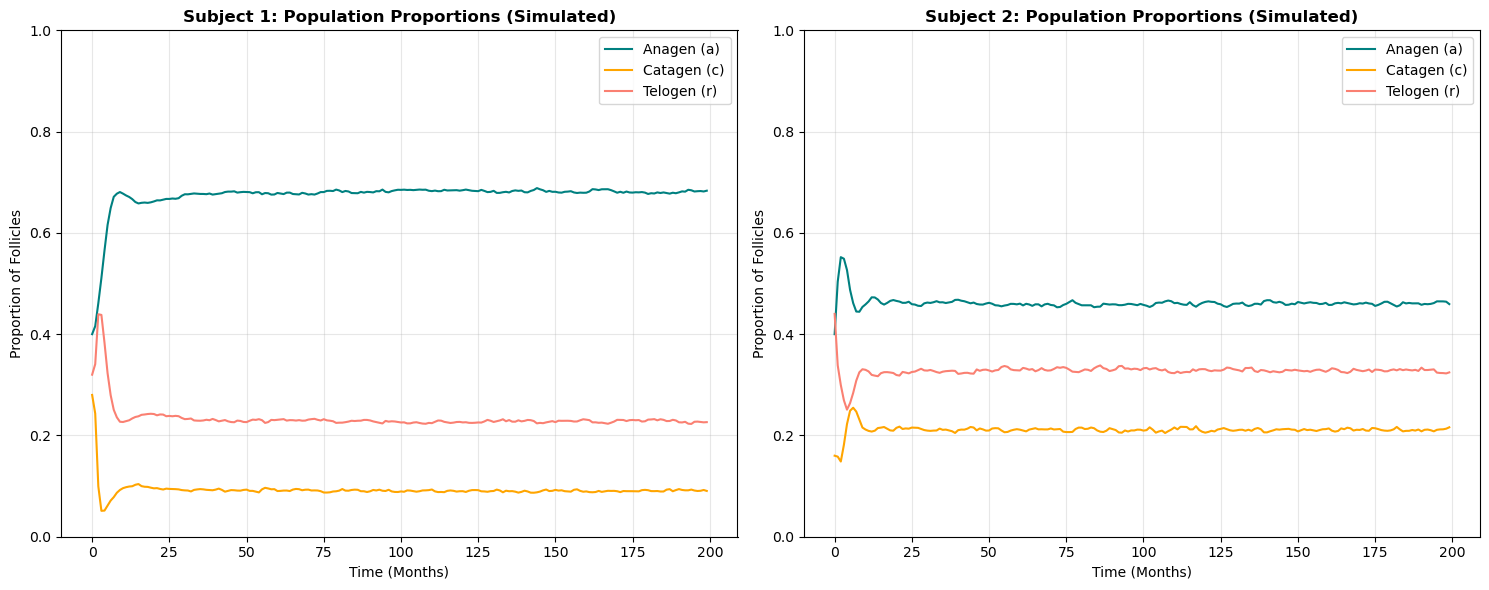

In [7]:
# -------------------------------------------------------------------
# Comparative Analysis of Subject Follicle Dynamics (baseline cycle)
# -------------------------------------------------------------------

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

labels = ['Anagen (a)', 'Catagen (c)', 'Telogen (r)']
colors = ['teal', 'orange', 'salmon']

# Plot Subject 1 (Left)
for i in range(3):
    axes[0].plot(results['Subject 1']['norm_data'][:, i], label=labels[i], color=colors[i])
axes[0].set_title('Subject 1: Population Proportions (Simulated)', fontweight='bold')
axes[0].set_xlabel('Time (Months)')
axes[0].set_ylabel('Proportion of Follicles')
axes[0].set_ylim(0, 1)  
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot Subject 2 (Right)
for i in range(3):
    axes[1].plot(results['Subject 2']['norm_data'][:, i], label=labels[i], color=colors[i])
axes[1].set_title('Subject 2: Population Proportions (Simulated)', fontweight='bold')
axes[1].set_xlabel('Time (Months)')
axes[1].set_ylabel('Proportion of Follicles')
axes[1].set_ylim(0, 1)  
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [8]:
# ----------------------------------------------------------
# Non-linear Regression of Hair Cycle Data (baseline cycle)
# Parameter Estimation & ODE Integration
# ----------------------------------------------------------

def system(t, x, alpha, beta, gamma):
    a, c, r = x
    da = alpha * r - beta * a
    dc = beta * a - gamma * c
    dr = gamma * c - alpha * r
    return [da, dc, dr]


def simulate(theta, t_eval, x0):
    alpha, beta, gamma = theta
    sol = solve_ivp(
        lambda t, x: system(t, x, alpha, beta, gamma),
        (t_eval[0], t_eval[-1]),
        x0,
        t_eval=t_eval
    )
    return sol.y.T 


def residuals(theta, t_eval, data, x0):
    pred = simulate(theta, t_eval, x0)
    return (data - pred).ravel()


# Initial guess for [alpha, beta, gamma]
theta0 = [0.1, 0.1, 0.1]
subjects = ["Subject 1", "Subject 2"]

for sub_name in subjects:
    # Retrieve the pre-processed normalized data and initial state
    norm_data = results[sub_name]['norm_data']
    x0 = results[sub_name]['x0']
    
    # Run the nonlinear regression to find best-fit parameters
    res = least_squares(
        residuals,                      # The function name
        theta0,                         # The first argument
        args=(t_data, norm_data, x0),   # The remaining arguments
        bounds=(0, np.inf),             # Ensures biological rates stay positive
        method='trf'                    # Trust Region Reflective (TRF) method of optimization
    )
    
    # Store full object, optimized parameters and the fitted simulations
    results[sub_name]['res_object'] = res 
    results[sub_name]['params'] = res.x
    results[sub_name]['Y_hat'] = simulate(res.x, t_data, x0)
    
    print(f"Finished fitting {sub_name}. Params: {res.x}")


Finished fitting Subject 1. Params: [0.22722147 0.0766344  0.57700229]
Finished fitting Subject 2. Params: [0.5145912  0.36411963 0.79313144]


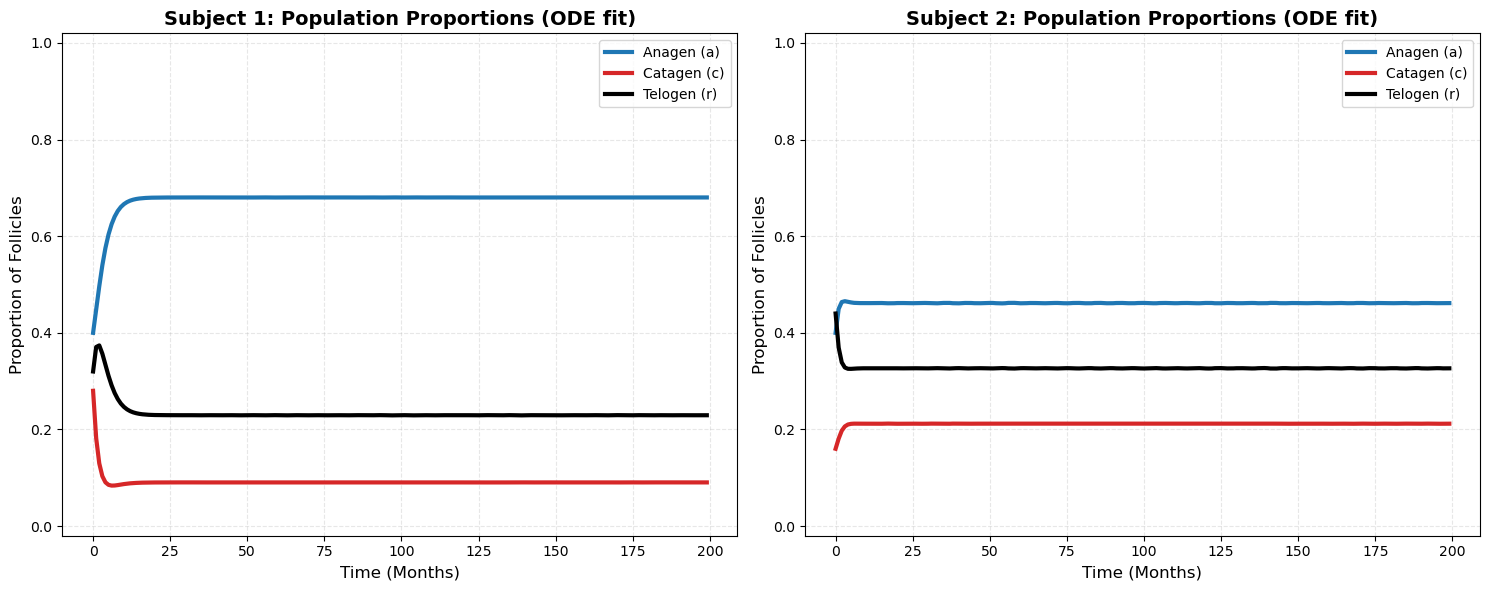

In [9]:
#----------------------------------------------------
# ODE fit plots for Hair Cycle Data (baseline cycle)
#----------------------------------------------------

colors = ['#1f77b4', '#d62728', '#000000']      # Blue (A/a), Red (C/c), Green (T/r)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for idx, sub_name in enumerate(subjects):
    ax = axes[idx]
    
    # Extract the fitted ODE data only
    fitted = results[sub_name]['Y_hat']
    
    for i in range(3):
        # Plot the fitted ODE
        ax.plot(t_data, fitted[:, i], color=colors[i], label=labels[i], linewidth=3)

    # Formatting
    ax.set_title(f'{sub_name}: Population Proportions (ODE fit)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Time (Months)', fontsize=12)
    ax.set_ylabel('Proportion of Follicles', fontsize=12)
    
    # Consistent scale
    ax.set_ylim(-0.02, 1.02) 
    ax.legend(loc='upper right', frameon=True)
    ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()


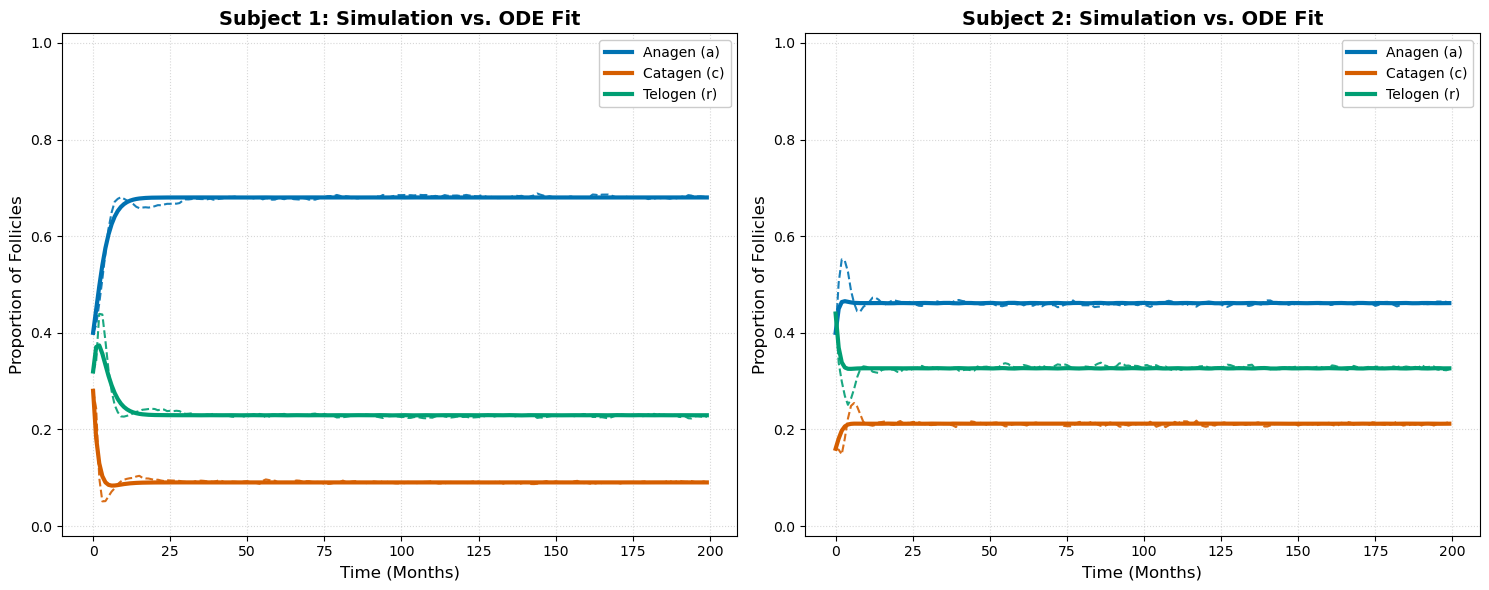

In [10]:
#------------------------------------------------------------------------------
# Hair Cycle Model: Parameter Estimation and Validation Plots (baseline cycle)
#------------------------------------------------------------------------------

colors = ['#0072B2', '#D55E00', '#009E73']  # Blue (A/a), Orange (C/c), Green (T/r)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for idx, sub_name in enumerate(subjects):
    ax = axes[idx]
    
    orig = results[sub_name]['norm_data']  # Simulated data
    fitted = results[sub_name]['Y_hat']      # ODE Fit
    
    for i in range(3):
        # Simulated Data (Dashed Line)
        ax.plot(t_data, orig[:, i], color=colors[i], linestyle='--', linewidth=1.5, alpha=0.9)
        
        # ODE Fitted Results (Solid Line)
        ax.plot(t_data, fitted[:, i], color=colors[i], label=labels[i], linewidth=3)

    # Formatting
    ax.set_title(f'{sub_name}: Simulation vs. ODE Fit', fontsize=14, fontweight='bold')
    ax.set_xlabel('Time (Months)', fontsize=12)
    ax.set_ylabel('Proportion of Follicles', fontsize=12)
    ax.set_ylim(-0.02, 1.02) 
    ax.legend(loc='upper right', framealpha=1)
    ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()


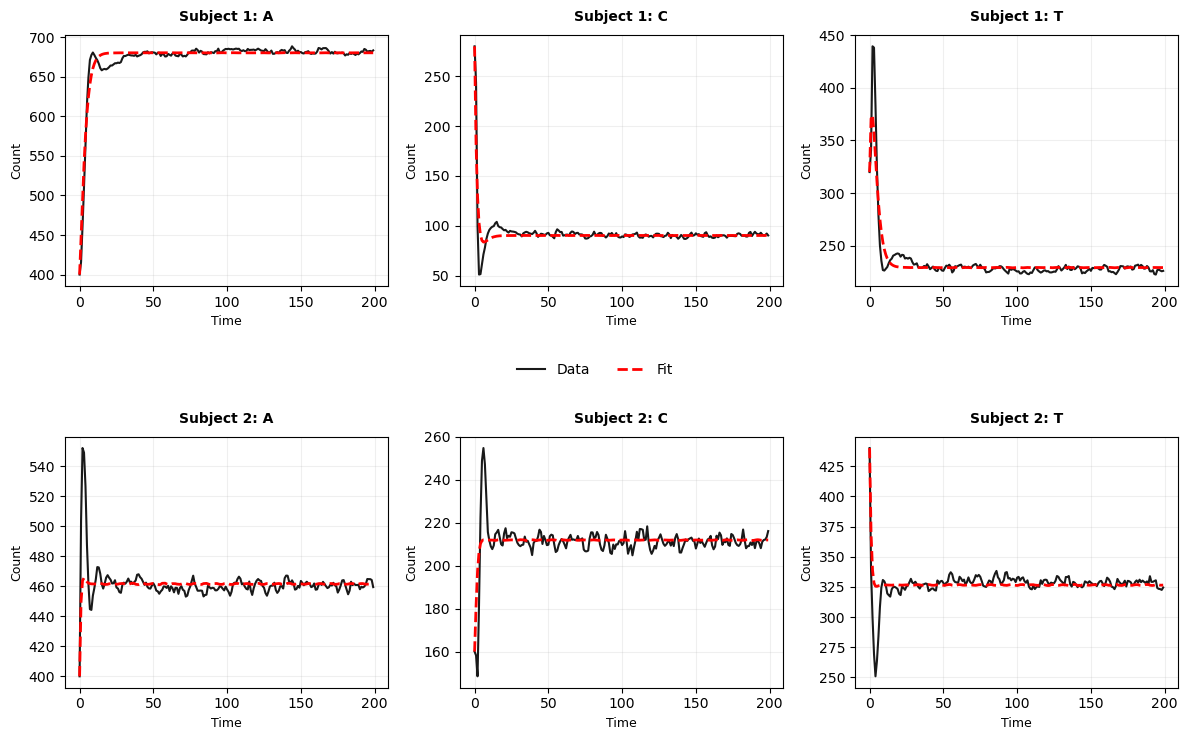

In [11]:
#---------------------------------------------------------------------------
# Fitting ODE Models to Simulated Hair Cycle Data (baseline cycle dynamics)
#---------------------------------------------------------------------------

labels = ['A', 'C', 'T']

fig, axs = plt.subplots(2, 3, figsize=(12, 7.5))

for row, sub_name in enumerate(subjects):
    orig = results[sub_name]['norm_data']
    fitted = results[sub_name]['Y_hat']
    
    for col in range(3):
        ax = axs[row, col]
        
        # Plotting
        l1, = ax.plot(t_data, orig[:, col] * N_value, '-', color='black', alpha=0.9, label='Data')
        l2, = ax.plot(t_data, fitted[:, col] * N_value, '--', color='red', linewidth=2, label='Fit')
        
        ax.set_title(f"{sub_name}: {labels[col]}", fontsize=10, fontweight='bold', pad=10)
        ax.set_xlabel('Time', fontsize=9)
        ax.set_ylabel('Count', fontsize=9)
        ax.grid(alpha=0.2)

# Placement of legend 
fig.legend(handles=[l1, l2], 
           loc='center', 
           bbox_to_anchor=(0.5, 0.5), 
           ncol=2, 
           frameon=True, 
           facecolor='white', 
           edgecolor='none')

# Tighten the layout
plt.tight_layout()
plt.subplots_adjust(hspace=0.6) 

plt.show()


In [12]:
#-----------------------------------------
# Compute RMSE (baseline cycle dynamics)
#-----------------------------------------

rmse_table = []

for sub_name in subjects:
    data = results[sub_name]['norm_data']
    pred = results[sub_name]['Y_hat']
    res = data - pred
    
    # Compute RMSE per phase and scale by N
    rmse_per_phase = np.sqrt(np.mean(res**2, axis=0)) * N_value
    
    rmse_table.append([sub_name, *rmse_per_phase])

# Display results
headers = ["Subject", "RMSE Phase A", "RMSE Phase C", "RMSE Phase T"]
print(tabulate(rmse_table, headers=headers, tablefmt="grid", floatfmt=".2f"))


+-----------+----------------+----------------+----------------+
| Subject   |   RMSE Phase A |   RMSE Phase C |   RMSE Phase T |
+===========+================+================+================+
| Subject 1 |           7.65 |           7.61 |          10.00 |
+-----------+----------------+----------------+----------------+
| Subject 2 |          11.25 |           7.08 |          10.15 |
+-----------+----------------+----------------+----------------+


The model fits the data very well. The RMSE indicates that predictions are typically within an error bound of approximately 15 follicles for each follicle state. To further assess the appropriateness of the model, we analyze the residuals to examine any remaining structure or systematic patterns not captured by the model.

In [13]:
#----------------------------------------------------
# Compute Standard Errors (baseline cycle dynamics)
#----------------------------------------------------

uncertainty_table = []

for sub_name in subjects:
    res = results[sub_name]['res_object'] 
    
    rr = res.fun    # Residuals
    J = res.jac     # Jacobian matrix
    
    n = len(rr)     # Number of data points (200 * 3)
    p = len(res.x)  # Number of parameters (3)

    sigma2 = (rr @ rr) / (n - p) 
    
    cov = sigma2 * np.linalg.inv(J.T @ J) 
    se = np.sqrt(np.diag(cov))
    
    uncertainty_table.append([sub_name, se[0], se[1], se[2]])

# Display the results
headers = ["Subject", "SE (Alpha)", "SE (Beta)", "SE (Gamma)"]
print(f"\nParameter Uncertainty (Standard Errors):")
print(tabulate(uncertainty_table, headers=headers, tablefmt="grid", floatfmt=".6f"))



Parameter Uncertainty (Standard Errors):
+-----------+--------------+-------------+--------------+
| Subject   |   SE (Alpha) |   SE (Beta) |   SE (Gamma) |
+===========+==============+=============+==============+
| Subject 1 |     0.004284 |    0.001470 |     0.010991 |
+-----------+--------------+-------------+--------------+
| Subject 2 |     0.008454 |    0.006009 |     0.013111 |
+-----------+--------------+-------------+--------------+


The standard error of parameters estimate is in the order of 0.01 which is acceptable.

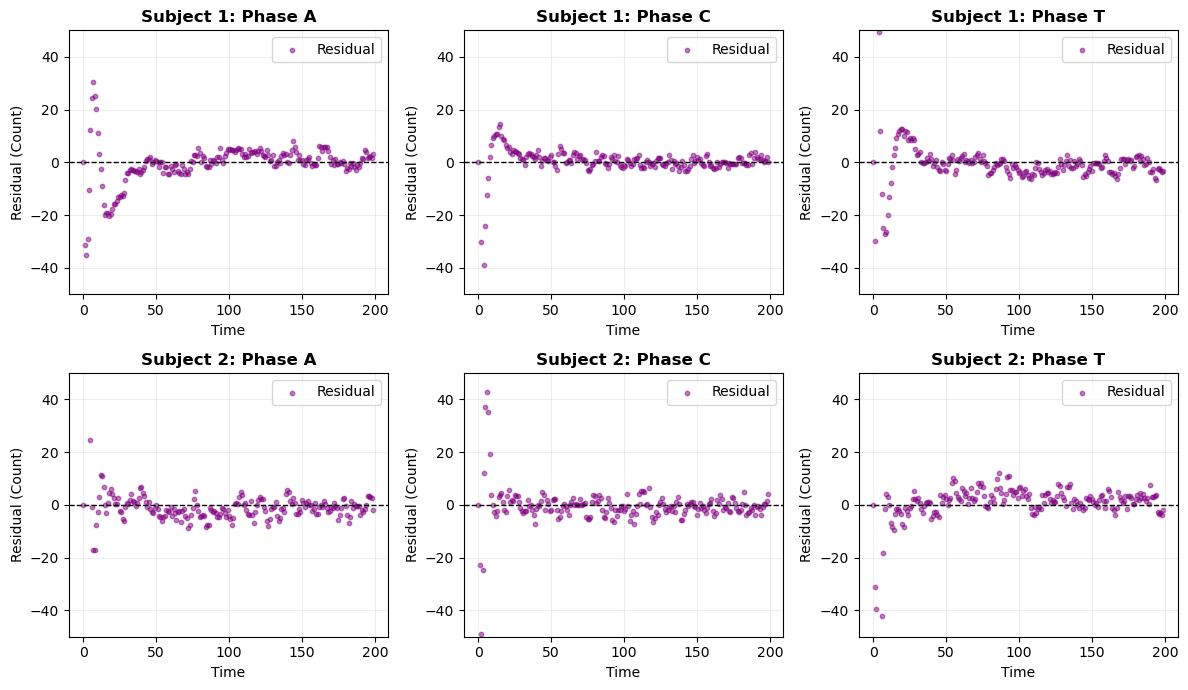

In [14]:
#-------------------------------------------------
# Residue scatter plots (baseline cycle dynamics)
#-------------------------------------------------

labels = ['Phase A', 'Phase C', 'Phase T']

fig, axs = plt.subplots(2, 3, figsize=(12, 7))

for row, sub_name in enumerate(subjects):
    # Retrieve norm-data and ODE fit
    data = results[sub_name]['norm_data']
    pred = results[sub_name]['Y_hat']
    
    res = (data - pred) * N_value 
    
    for col in range(3):
        ax = axs[row, col]
        
        ax.scatter(t_data, res[:, col], s=10, alpha=0.5, color='purple', label='Residual')
        
        ax.axhline(0, color='black', linestyle='--', linewidth=1)
        
        ax.set_title(f"{sub_name}: {labels[col]}", fontweight='bold')
        ax.set_xlabel('Time')
        ax.set_ylabel('Residual (Count)')
        
        ax.set_ylim(-50, 50) 
        
        ax.grid(alpha=0.2)
        ax.legend(loc='upper right')

plt.tight_layout()
plt.show()


In [15]:
#----------------------------------------------------------------------
# Perform Engle's ARCH test on the residuals (baseline cycle dynamics)
#----------------------------------------------------------------------

arch_results = []

for sub_name in ["Subject 1", "Subject 2"]:
    rr = results[sub_name]['res_object'].fun
    res_matrix = rr.reshape((200, 3))
    subject_row = [sub_name]
    
    for i in range(3):
        f_arch, p_arch = het_arch(res_matrix[:, i])[-2:]
        
        subject_row.append(f"{f_arch:.2f} / {p_arch:.2e}")
        
    arch_results.append(subject_row)

headers = ["Subject", "Phase A (F/p)", "Phase C (F/p)", "Phase T (F/p)"]
print(tabulate(arch_results, headers=headers, tablefmt="grid"))


+-----------+--------------------+-------------------+-------------------+
| Subject   | Phase A (F/p)      | Phase C (F/p)     | Phase T (F/p)     |
+===========+====================+===================+===================+
| Subject 1 | 343.27 / 4.01e-111 | 152.11 / 6.13e-82 | 187.06 / 3.58e-89 |
+-----------+--------------------+-------------------+-------------------+
| Subject 2 | 22.80 / 3.60e-27   | 1.59 / 1.14e-01   | 11.27 / 7.45e-15  |
+-----------+--------------------+-------------------+-------------------+


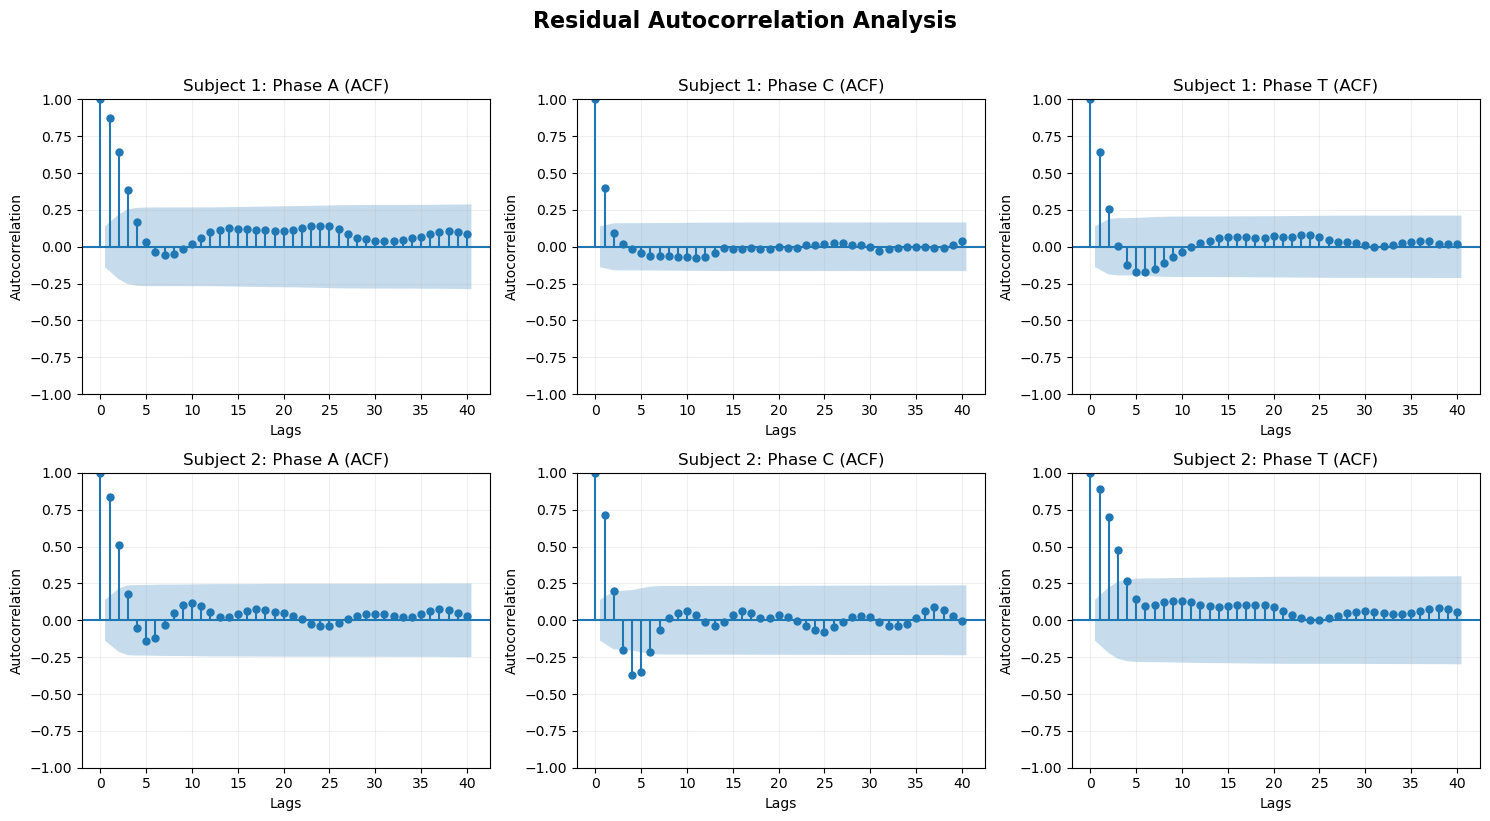

In [16]:
#---------------------------------------
# Residual Autocorrelation Analysis
#---------------------------------------

labels = ['Phase A', 'Phase C', 'Phase T']
subjects = ["Subject 1", "Subject 2"]

# 2 rows (one per subject), 3 columns (one per phase)
fig, axs = plt.subplots(2, 3, figsize=(15, 8))

for row, sub_name in enumerate(subjects):
    # 1. Retrieve and reshape residuals to (T_end_value, 3)
    rr = results[sub_name]['res_object'].fun
    res_matrix = rr.reshape((T_end_value, 3))
    
    for col in range(3):
        ax = axs[row, col]
        
        # 2. Plot ACF for the specific phase on the correct subplot axis
        # Suppress double-plotting by assigning to '_'
        _ = plot_acf(res_matrix[:, col], lags=40, ax=ax, title=f"{sub_name}: {labels[col]} (ACF)")
        
        # Formatting for readability
        ax.set_xlabel("Lags")
        ax.set_ylabel("Autocorrelation")
        ax.grid(alpha=0.2)

# Global title and adjustment
fig.suptitle("Residual Autocorrelation Analysis", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


The residuals are not random; instead, they exhibit a clear exponentially decaying pattern. This indicates that the model fails to fully capture the underlying dynamics of the follicle cycle. The primary limitation arises from the linear SIR-type formulation, which assumes memoryless transitions between states. Such an assumption is not appropriate for biological systems like hair follicles, where the duration spent in each phase influences transition behavior.

Further evidence of model inadequacy is seen in the autocorrelation function (ACF), which shows that the residuals are not white noise and retain temporal structure. This confirms that important dynamics are missing from the model.

To address these issues, we introduced subcompartments within the anagen and telogen states. This modification allows the model to approximate non-exponential (non-memoryless) dwell-time distributions, thereby incorporating implicit memory into the system and improving its ability to capture the observed follicle dynamics.

In [ ]:
#----- WORK IN PROGRESS: I AM CURRENTLY HERE --------------

## Sub-compartmentalization

In [ ]:
# add subcompartments
def follicle_subcomp_model(t, y, alpha, beta, gamma):
    """
    States:
        y = [t1, t2, a1, a2, c]

    Aggregated:
        T = t1 + t2
        A = a1 + a2
        C = c
    """
    t1, t2, a1, a2, c = y
    # split t into t1 and t2
    dt1 = gamma * c - alpha * t1
    dt2 = alpha * t1 - alpha * t2
    #split a into a1 and a2
    da1 = alpha * t2 - beta * a1
    da2 = beta * a1 - beta * a2
    dc  = beta * a2 - gamma * c

    return [dt1, dt2, da1, da2, dc]


In [ ]:
# unknown initial setup
def build_initial_state(A0, C0, T0, rhoT=0.5, rhoA=0.5):
    """
    Split observed initial A0,T0 into hidden substates.

    rhoT: fraction of T0 placed in t1
    rhoA: fraction of A0 placed in a1
    """
    t1_0 = rhoT * T0
    t2_0 = (1.0 - rhoT) * T0
    a1_0 = rhoA * A0
    a2_0 = (1.0 - rhoA) * A0
    c_0  = C0

    y0 = np.array([t1_0, t2_0, a1_0, a2_0, c_0], dtype=float)
    return y0

In [ ]:
# simulate
def solve_model(times, params, A0, C0, T0):
    """
    params = [kT, kA, gamma, rhoT, rhoA]
    """
    alpha, beta, gamma= params

    y0 = build_initial_state(A0, C0, T0)

    sol = solve_ivp(
        fun=lambda t, y: follicle_subcomp_model(t, y, alpha, beta, gamma),
        t_span=(times[0], times[-1]),
        y0=y0,
        t_eval=times,
        method="RK45",
        vectorized=False,
        rtol=1e-7,
        atol=1e-9
    )

    t1, t2, a1, a2, c = sol.y
    #convert back into a single compartment for computing error
    T_pred = t1 + t2 
    A_pred = a1 + a2
    C_pred = c

    return {
        "t1": t1,
        "t2": t2,
        "a1": a1,
        "a2": a2,
        "c": c,
        "T_pred": T_pred,
        "A_pred": A_pred,
        "C_pred": C_pred,
    }


In [ ]:
# loss
def residuals(params, times, A_obs, C_obs, T_obs):
    kT, kA, gamma= params

    # # enforce positivity / bounds softly
    # if kT <= 0 or kA <= 0 or gamma <= 0:
    #     return 1e6 * np.ones(3 * len(times))
    # if not (0.0 <= rhoT <= 1.0 and 0.0 <= rhoA <= 1.0):
    #     return 1e6 * np.ones(3 * len(times))

    A0, C0, T0 = A_obs[0], C_obs[0], T_obs[0]

    # try:
    out = solve_model(times, params, A0, C0, T0)
    # except Exception:
    #     return 1e6 * np.ones(3 * len(times))

    A_pred = out["A_pred"]
    C_pred = out["C_pred"]
    T_pred = out["T_pred"]

    # concatenate all residuals
    resA = A_pred - A_obs
    resC = C_pred - C_obs
    resT = T_pred - T_obs

    return np.concatenate([resA, resC, resT])


In [ ]:
#A_obs, C_obs, T_obs = a, c, r
p0 = np.array([0.2, 0.2, 0.2], dtype=float)
result  = least_squares(
        fun=residuals,
        x0=p0,
        #bounds=bounds,
        args=(t_data, a,c,r),
        method="trf",
        verbose=1
    )

In [ ]:
#simulation: with subcompartment
theta= result.x
a0, c0, t0 = norm_data[0]
out= solve_model(t_data, theta, a0, c0, t0)

In [ ]:
# Better transient response
lables =['A','C','T']
fig, axs = plt.subplots(1, 3, figsize=(10, 3))
for i, ax in enumerate(axs.ravel()):
    ax.plot(t_data[0:], norm_data[0:,i]*N, '-', linewidth=1.5, mfc='none', ms=5.5, mew=1.5, label='data')
    ax.plot(t_data[0:], out[f'{lables[i]}_pred']*N, '--', linewidth=1.5, mfc='none', ms=5.5, mew=1.5, label='fit')
    ax.set_title(lables[i])
    # Set axes labels and legends
    ax.set_xlabel('time')
    ax.set_ylabel('x')
    ax.legend(loc='lower right')

plt.tight_layout()

Demonistarted better transient response.

In [ ]:
# residue scatter plot
res = result.fun.reshape((200,3))
act = [A_avg,C_avg,T_avg]
lables =['A','C','T']
fig, axs = plt.subplots(1, 3, figsize=(10, 3))
for i, ax in enumerate(axs.ravel()):
    ax.plot(t_data[0:], res[0:,i]*10000, '--', linewidth=1.5, mfc='none', ms=5.5, mew=1.5, label='fit')
    #ax.scatter(t_data, res[:,i], label='fit')
    ax.set_title(lables[i])
    # Set axes labels and legends
    ax.set_xlabel('time')
    ax.set_ylabel('x')
    ax.legend(loc='lower right')

plt.tight_layout()

In [ ]:
for i in range(3):
    fig = plot_acf(res[:,i], lags=40)
 

The scatter plot doesn't show any pattern. The autoregression shows that the residue is white noise. So the model assumptions are ppropariate and the model is able to capture the dynamics of the follicle cycle.

# III Parameter Sensitivity and Hair Treatment 

In [ ]:
print(f'The parameters of the ODE : alpha, beta and gamma are {result.x[:3]}')

In [ ]:
for i in range(3):
    plt.plot(t_data, out[f'{lables[i]}_pred']*N,label=['A','C','T'][i])
plt.grid()
plt.legend()

In [ ]:
#simulation: with subcompartment
theta= result.x
#reduce alpha by halph
theta[0] = theta[0]/2
a0, c0, t0 = norm_data[0]
out= solve_model(t_data, theta, a0, c0, t0)

In [ ]:
for i in range(3):
    plt.plot(t_data, out[f'{lables[i]}_pred']*N,label=['A','C','T'][i])
plt.grid()
plt.legend()

We observe that when alpha is reduced—corresponding to an increased Wnt activation threshold—the transition into the anagen phase decreases. As a result, the proportion of follicles in anagen becomes lower than that in catagen. This shift indicates reduced hair growth activity and suggests a higher susceptibility to hair loss (baldness).